# 🎯 **Домашнее задание к семинару 07 (HW07)**
Кластеризация, внутренние метрики качества, PCA/t-SNE и честный unsupervised-эксперимент

В этом ноутбуке выполняется честный unsupervised-эксперимент по сравнению алгоритмов кластеризации в едином протоколе.

В ходе работы:

* используются **три синтетических датасета** (S07-hw-dataset-01, S07-hw-dataset-02, S07-hw-dataset-04), каждый с уникальными особенностями (разные шкалы, нелинейные структуры, категориальные признаки и пропуски);
* данные проходят **единый препроцессинг**: масштабирование числовых признаков, обработка пропусков, кодирование категориальных признаков (если есть);
* обучаются и сравниваются алгоритмы недели 7:

  * **KMeans** (подбор числа кластеров k, фиксация random_state и n_init),
  * **DBSCAN** или **AgglomerativeClustering** (подбор параметров eps/min_samples или k/linkage);
* качество кластеризации оценивается по **внутренним метрикам**: silhouette score, Davies–Bouldin score, Calinski–Harabasz score;
* для DBSCAN учитывается шум (-1) и его доля, метрики считаются корректно для non-noise точек;
* визуализируются результаты через **PCA(2D) scatter** (t-SNE опционально), демонстрируя разбиение на кластеры и локальную структуру данных;
* проводится **мини-проверка устойчивости** алгоритма на одном из датасетов (например, KMeans с разными random_state);
* артефакты эксперимента (метрики, лучшие конфигурации, присвоенные метки кластеров, графики) сохраняются в папку `artifacts/`.

**Цель эксперимента** — не максимизировать метрики, а продемонстрировать инженерно корректный, воспроизводимый и честный протокол для unsupervised-задачи: от данных → через препроцессинг → к кандидатам → сравнение и интерпретация.

# 0. Импорты и базовые настройки

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import os

FIGURES_DIR = "homeworks/HW07/artifacts/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# 1. Загрузка датасета и первичный анализ

Для домашнего задания используются три синтетических датасета: **S07-hw-dataset-01.csv**, **S07-hw-dataset-02.csv** и **S07-hw-dataset-04.csv**.

Каждый датасет представляет собой **табличные данные без истинных меток кластеров**, с различными особенностями:

* числовые признаки в разных шкалах, шумовые признаки (ds1),
* нелинейные структуры и выбросы (ds2),
* высокоразмерные данные с категориальными признаками и пропусками (ds4).

На этом шаге для каждого датасета выполняется:

1. Загрузка данных в `pandas.DataFrame` с помощью `pd.read_csv`;
2. Вывод первых строк таблицы (`head()`), чтобы получить первичное представление о структуре данных;
3. Анализ типов столбцов, наличие пропусков и базовая статистика числовых признаков (`info()`, `describe()`);
4. Определение матрицы признаков **X** (все столбцы, кроме `sample_id`) и сохранение идентификаторов **sample_id** отдельно для последующего сохранения результатов;
5. При необходимости определение категориальных признаков для дальнейшего кодирования.

Эта процедура обеспечивает единый подход к первичному анализу всех выбранных датасетов перед применением алгоритмов кластеризации.


In [2]:
# Загружаем датасет
path = 'https://raw.githubusercontent.com/TatjanaYMIREA/aie-group-2/main/homeworks/HW07/data/S07-hw-dataset-'
import pandas as pd

# Пути к датасетам
data_paths = {
    "ds1": path + "01.csv",
    "ds2": path + "02.csv",
    "ds4": path + "04.csv"
}

# Словари для хранения данных
datasets = {}
X_data = {}
sample_ids = {}
categorical_features = {}

for name, path in data_paths.items():
    print(f"\n=== Загрузка и первичный анализ {name} ===")

    # 1. Загрузка
    df = pd.read_csv(path)
    datasets[name] = df

    # 2. Первичный просмотр
    print("Первые строки:")
    display(df.head())

    print("\nИнформация о столбцах:")
    print(df.info())

    print("\nБазовая статистика:")
    display(df.describe(include='all'))

    # 3. Проверка пропусков
    missing_count = df.isna().sum()
    missing_ratio = df.isna().mean()
    print("\nПропуски по столбцам (кол-во / доля):")
    print(pd.DataFrame({"missing_count": missing_count, "missing_ratio": missing_ratio}))

    # 4. Определение признаков
    sample_ids[name] = df['sample_id']

    # Выбираем все столбцы, кроме sample_id
    X = df.drop(columns=['sample_id'])

    # Определяем категориальные признаки
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    categorical_features[name] = cat_cols

    X_data[name] = X

    print(f"\nПризнаки для модели: {X.columns.tolist()}")
    print(f"Категориальные признаки: {cat_cols}")


=== Загрузка и первичный анализ ds1 ===
Первые строки:


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213



Информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB
None

Базовая статистика:


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,5999.50000,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,3464.24595,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,0.00000,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,2999.75000,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,5999.50000,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,8999.25000,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,11999.00000,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745



Пропуски по столбцам (кол-во / доля):
           missing_count  missing_ratio
sample_id              0            0.0
f01                    0            0.0
f02                    0            0.0
f03                    0            0.0
f04                    0            0.0
f05                    0            0.0
f06                    0            0.0
f07                    0            0.0
f08                    0            0.0

Признаки для модели: ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08']
Категориальные признаки: []

=== Загрузка и первичный анализ ds2 ===
Первые строки:


...


Пропуски по столбцам (кол-во / доля):
           missing_count  missing_ratio
sample_id              0            0.0
x1                     0            0.0
x2                     0            0.0
z_noise                0            0.0

Признаки для модели: ['x1', 'x2', 'z_noise']
Категориальные признаки: []

=== Загрузка и первичный анализ ds4 ===
Первые строки:


,sample_id,cat_a,cat_b,n01,n02,n03,n04,n05,n06,n07,...,n21,n22,n23,n24,n25,n26,n27,n28,n29,n30
0,0,B,X,-4.827501,-24.507466,-7.852963,0.771781,28.297884,-4.493911,-42.769449,...,24.597176,-26.354320,4.543397,-19.549036,-3.051332,-5.538587,-3.084457,5.499629,-6.128896,3.132067
1,1,F,V,51.302500,NaN,5.534737,51.305464,-8.027553,28.297548,NaN,...,-18.216260,8.527932,17.202115,-30.452260,0.855326,1.199066,3.597555,-2.239703,2.932710,0.473145
2,2,A,W,-4.820828,-2.625385,27.891578,1.523041,-5.776687,-16.298523,2.462937,...,-48.260775,9.313232,12.323411,55.081325,-3.945606,-0.280540,-0.130583,-7.353205,-2.942836,1.460477
3,3,B,X,-2.627573,-25.063639,-9.450011,-8.344669,22.371118,-11.525848,-43.762607,...,24.700663,-25.466915,-3.398665,-18.174541,0.438229,3.152556,3.859283,-2.678769,-2.213923,-4.724639
4,4,C,Y,-11.415710,-8.692169,48.636163,14.661826,-39.634618,10.769075,40.187536,...,-79.710383,-13.694253,41.575892,-9.498640,1.529608,-1.641347,3.500090,3.111257,1.475232,-1.321676



Информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  10000 non-null  int64  
 1   cat_a      10000 non-null  object 
 2   cat_b      10000 non-null  object 
 3   n01        9826 non-null   float64
 4   n02        9811 non-null   float64
 5   n03        9801 non-null   float64
 6   n04        9808 non-null   float64
 7   n05        9799 non-null   float64
 8   n06        9817 non-null   float64
 9   n07        9796 non-null   float64
 10  n08        9806 non-null   float64
 11  n09        9805 non-null   float64
 12  n10        9811 non-null   float64
 13  n11        9796 non-null   float64
 14  n12        9798 non-null   float64
 15  n13        9803 non-null   float64
 16  n14        9802 non-null   float64
 17  n15        9814 non-null   float64
 18  n16        9809 non-null   float64
 19  n17        9788 non-nul

,sample_id,cat_a,cat_b,n01,n02,n03,n04,n05,n06,n07,...,n21,n22,n23,n24,n25,n26,n27,n28,n29,n30
count,10000.00000,10000,10000,9826.000000,9811.000000,9801.000000,9808.000000,9799.000000,9817.000000,9796.000000,...,9785.000000,9804.000000,9829.000000,9793.000000,9815.000000,9776.000000,9803.000000,9789.000000,9798.000000,9805.000000
unique,NaN,6,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,E,V,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1692,1682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4999.50000,NaN,NaN,17.348435,-2.057620,7.908302,14.269157,0.900590,5.832787,-0.840875,...,-12.716502,-0.506241,8.360226,0.026943,0.039297,-0.037155,0.028512,-0.030738,-0.018685,-0.030254
std,2886.89568,NaN,NaN,22.578551,19.043410,25.637807,18.815319,20.981294,13.221646,26.583849,...,37.290305,14.336833,17.754646,26.121335,3.009995,3.020813,3.028106,3.000090,3.014209,3.014573
min,0.00000,NaN,NaN,-22.437090,-37.546998,-38.136412,-23.374316,-45.914070,-20.650038,-60.297304,...,-89.640783,-35.102360,-25.014050,-49.423300,-11.225848,-14.446922,-10.840777,-11.679259,-11.437909,-11.491223
25%,2499.75000,NaN,NaN,-3.975438,-14.200552,-8.591513,-1.223379,-5.086756,-4.532057,-13.554720,...,-41.284671,-11.563652,-2.123576,-19.425213,-1.973213,-2.082235,-2.007628,-2.074500,-2.051778,-2.074396
50%,4999.50000,NaN,NaN,22.042807,-6.532183,0.350400,10.069142,2.413111,7.391953,-2.429024,...,-1.145681,2.491416,6.691365,-8.464171,0.037806,-0.033336,0.031588,-0.043127,-0.015441,-0.015903
75%,7499.25000,NaN,NaN,37.535647,2.092197,30.725630,29.807101,18.398883,13.033076,16.095731,...,18.916379,11.903004,14.939690,16.861978,2.048648,2.019027,2.056870,1.980217,2.013964,2.031215



Пропуски по столбцам (кол-во / доля):
           missing_count  missing_ratio
sample_id              0         0.0000
cat_a                  0         0.0000
cat_b                  0         0.0000
n01                  174         0.0174
n02                  189         0.0189
n03                  199         0.0199
n04                  192         0.0192
n05                  201         0.0201
n06                  183         0.0183
n07                  204         0.0204
n08                  194         0.0194
n09                  195         0.0195
n10                  189         0.0189
n11                  204         0.0204
n12                  202         0.0202
n13                  197         0.0197
n14                  198         0.0198
n15                  186         0.0186
n16                  191         0.0191
n17                  212         0.0212
n18                  212         0.0212
n19                  187         0.0187
n20                  203         0.0203
n

## <font color="blue">📝 Наблюдения по датасетам</font>

**ds1 (S07-hw-dataset-01.csv)**

* В датасете **12 000 объектов** и **8 числовых признаков** (без учёта `sample_id`).
* Пропусков нет, все значения заполнены.
* Признаки находятся в сильно различающихся шкалах: например, `f02` варьируется от примерно -93 до 112, а `f08` — от -2.6 до 2.5.
* Явно некорректных значений нет, но различие в масштабах потребует **масштабирования** перед применением алгоритмов на основе расстояний (KMeans, DBSCAN).
* Категориальных признаков нет, все признаки числовые.

---

**ds2 (S07-hw-dataset-02.csv)**

* В датасете **8 000 объектов** и **3 признака** (2 полезных + 1 шумовой).
* Пропусков нет, все значения заполнены.
* Наблюдаются признаки с явно выраженным шумом (`z_noise`), что может влиять на алгоритмы, чувствительные к выбросам.
* Признаки находятся примерно в диапазоне [-3, 3] для полезных и [-35, 30] для шумового признака.
* Категориальных признаков нет.
* Этот датасет демонстрирует **нелинейную структуру и выбросы**, что может усложнить работу KMeans и сделать интересным применение DBSCAN или иерархических методов.

---

**ds4 (S07-hw-dataset-04.csv)**

* В датасете **10 000 объектов** и **32 признака** (2 категориальных + 30 числовых).
* Пропуски присутствуют в числовых признаках, примерно 1.7–2.2% значений по каждому столбцу, что требует **импутации**.
* Два категориальных признака (`cat_a`, `cat_b`) с несколькими уникальными значениями, которые нужно **кодировать** перед применением алгоритмов, чувствительных к числовым данным.
* Числовые признаки имеют широкий разброс значений (например, `n01` от -22 до 65, `n26` от -10 до 11).
* Высокая размерность и смешанные типы признаков делают этот датасет хорошей демонстрацией необходимости аккуратного **препроцессинга**.



# 2. Препроцессинг данных

На этом этапе для каждого датасета выполняется **явный и воспроизводимый препроцессинг**, который применяется одинаково ко всем моделям данного датасета.

Основные шаги:

1. **Масштабирование числовых признаков**

   * Используется `StandardScaler`, чтобы привести все числовые признаки к нулевому среднему и единичной дисперсии.
   * Особенно важно для датасетов с признаками в разных шкалах (например, DS1 и DS4), чтобы алгоритмы на основе расстояний (KMeans, DBSCAN, AgglomerativeClustering) корректно воспринимали все признаки.

2. **Обработка пропусков**

   * Для числовых признаков используется `SimpleImputer` со стратегией `median`, чтобы заполнить отсутствующие значения.
   * В датасетах DS1 и DS2 пропусков нет, а в DS4 доля пропусков небольшая (~1.7–2.2% на столбец), что позволяет корректно применять импутацию.

3. **Обработка категориальных признаков**

   * В DS4 присутствуют два категориальных признака (`cat_a`, `cat_b`).
   * Для работы с ними используется **OneHotEncoder(handle_unknown="ignore")**, чтобы преобразовать их в числовой формат, не нарушая размерность при появлении неизвестных категорий в будущем.
   * Для других датасетов категориальных признаков нет.

4. **Использование Pipeline/ColumnTransformer**

   * Для удобства и воспроизводимости создаются пайплайны, объединяющие:

     * обработку числовых признаков (импутация + масштабирование),
     * обработку категориальных признаков (кодирование).
   * Такой подход гарантирует, что **одинаковая процедура препроцессинга** применяется ко всем моделям на данном датасете.


In [3]:
# Словари для хранения пайплайнов и преобразованных данных
preprocessors = {}
X_preprocessed = {}

for name, X in X_data.items():
    print(f"\n=== Препроцессинг {name} ===")

    # Определяем числовые и категориальные признаки
    num_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
    # Исключаем sample_id, если он ещё остался
    if 'sample_id' in num_cols:
        num_cols.remove('sample_id')

    cat_cols = categorical_features[name]

    # Пайплайн для числовых признаков: медиана + масштабирование
    num_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    # Пайплайн для категориальных признаков (если есть)
    if cat_cols:
        cat_pipeline = Pipeline(steps=[
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ])
    else:
        cat_pipeline = 'passthrough'

    # ColumnTransformer объединяет числовые и категориальные пайплайны
    preprocessor = ColumnTransformer(transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ])

    # Применяем преобразования к данным
    X_transformed = preprocessor.fit_transform(X)

    # Сохраняем пайплайн и преобразованные данные
    preprocessors[name] = preprocessor
    X_preprocessed[name] = X_transformed

    print(f"Признаки после препроцессинга: {X_transformed.shape}")


=== Препроцессинг ds1 ===
Признаки после препроцессинга: (12000, 8)

=== Препроцессинг ds2 ===
Признаки после препроцессинга: (8000, 3)

=== Препроцессинг ds4 ===
Признаки после препроцессинга: (10000, 42)


## <font color="blue">📝 Интерпретация препроцессинга</font>

**ds1**

* После препроцессинга получена матрица признаков размером **12 000 × 8**.
* Все числовые признаки были масштабированы к нулевому среднему и единичной дисперсии.
* Пропусков в датасете не было, поэтому медианная импутация фактически не изменила данные.
* Категориальных признаков нет.

**ds2**

* После препроцессинга матрица признаков имеет размер **8 000 × 3**.
* Все признаки числовые и масштабированы.
* Пропусков нет.
* Датасет содержит шумовой признак, который также масштабирован, что позволит алгоритмам кластеризации корректно оценивать расстояния.

**ds4**

* После препроцессинга матрица признаков имеет размер **10 000 × 42**.
* Исходно 30 числовых признаков и 2 категориальных, которые после кодирования через OneHotEncoder расширились до 42 признаков.
* Пропуски числовых признаков были заполнены медианой, что обеспечивает полную матрицу для моделей.
* Все числовые признаки масштабированы; категориальные признаки преобразованы в бинарные колонки, готовые к использованию KMeans, DBSCAN и AgglomerativeClustering.

**Вывод:**
Препроцессинг успешно привёл все датасеты к форме, пригодной для алгоритмов кластеризации: все числовые признаки масштабированы, пропуски обработаны, категориальные признаки кодированы, что гарантирует корректное сравнение моделей на каждом датасете.

## Формирование признакового пространства

После применения препроцессинга формируется итоговое признаковое пространство `X_feat`,
которое используется как единый вход для всех алгоритмов кластеризации.

На данном этапе опционально может применяться PCA для снижения размерности и подавления шума.
В текущем эксперименте PCA не используется, и `X_feat` совпадает с результатом препроцессинга.

In [4]:
RANDOM_STATE = 42

# Словарь для финальных признаков
X_feat = {}

# Настройка PCA (None — не используем)
pca_dim = None  # например: 10, если решишь добавить PCA

for name, X_tr in X_preprocessed.items():
    print(f"\n=== Формирование X_feat для {name} ===")

    if pca_dim is None:
        X_feat[name] = X_tr
        print("PCA не используется")
    else:
        pca = PCA(n_components=pca_dim, random_state=RANDOM_STATE)
        X_feat[name] = pca.fit_transform(X_tr)
        print(f"PCA: {X_tr.shape[1]} → {pca_dim}")

    print("X_feat shape:", X_feat[name].shape)


=== Формирование X_feat для ds1 ===
PCA не используется
X_feat shape: (12000, 8)

=== Формирование X_feat для ds2 ===
PCA не используется
X_feat shape: (8000, 3)

=== Формирование X_feat для ds4 ===
PCA не используется
X_feat shape: (10000, 42)


# 3. Настройки эксперимента и вспомогательные функции

Перед применением алгоритмов кластеризации зафиксируем единый протокол эксперимента, который будет использоваться для всех выбранных датасетов.

В рамках эксперимента:

- используются только **внутренние метрики качества** (без истинных меток кластеров);
- фиксируются диапазоны гиперпараметров для сравнения алгоритмов;
- используется единый препроцессинг для всех моделей внутри одного датасета;
- визуализация выполняется с помощью **PCA(2D)** исключительно для интерпретации результатов.

Для оценки качества кластеризации применяются следующие метрики:
- **Silhouette score** (выше — лучше),
- **Davies–Bouldin score** (ниже — лучше),
- **Calinski–Harabasz score** (выше — лучше).

Для алгоритма DBSCAN отдельно учитывается шум (метка `-1`):
- фиксируется доля шумовых точек,
- метрики считаются только по non-noise объектам.

Все функции и параметры зафиксированы явно, что обеспечивает воспроизводимость и честное сравнение алгоритмов.


## Настройки и вспомогательные функции

In [5]:
# Общие настройки эксперимента
RANDOM_STATE = 42

# Диапазон числа кластеров для KMeans
kmeans_ks = list(range(2, 21))

# Сетка параметров для DBSCAN
# Значения eps указаны для данных после StandardScaler
dbscan_eps = [0.5, 1.0, 1.5, 2.0, 2.5]
dbscan_min_samples = [3, 5, 10]

# Параметры для AgglomerativeClustering
agg_ks = list(range(2, 21))
agg_linkages = ["ward", "complete", "average"]

print("Experiment configuration:")
print(" KMeans k:", (kmeans_ks[0], "...", kmeans_ks[-1]))
print(" DBSCAN eps:", dbscan_eps)
print(" DBSCAN min_samples:", dbscan_min_samples)
print(" Agglomerative k:", (agg_ks[0], "...", agg_ks[-1]))
print(" Agglomerative linkages:", agg_linkages)
print(" RANDOM_STATE:", RANDOM_STATE)

Experiment configuration:
 KMeans k: (2, '...', 20)
 DBSCAN eps: [0.5, 1.0, 1.5, 2.0, 2.5]
 DBSCAN min_samples: [3, 5, 10]
 Agglomerative k: (2, '...', 20)
 Agglomerative linkages: ['ward', 'complete', 'average']
 RANDOM_STATE: 42


## Функции оценки качества кластеризации

In [6]:
def safe_cluster_metrics(X, labels):
    """
    Вычисляет внутренние метрики качества кластеризации.
    Возвращает None, если метрики неприменимы.
    """
    unique_labels = np.unique(labels)

    # Нужно минимум 2 кластера
    if len(unique_labels) < 2:
        return None

    try:
        sil = silhouette_score(X, labels)
    except Exception:
        sil = None

    try:
        db = davies_bouldin_score(X, labels)
    except Exception:
        db = None

    try:
        ch = calinski_harabasz_score(X, labels)
    except Exception:
        ch = None

    return {
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch
    }

## PCA(2D) для визуализации кластеров

In [24]:
def pca_2d_for_plot(X, random_state=RANDOM_STATE):
    """
    PCA до 2 компонент исключительно для визуализации.
    """
    pca = PCA(n_components=2, random_state=random_state)
    return pca.fit_transform(X)


def plot_2d_embedding(emb2d, labels, title, save_path=None):
    plt.figure(figsize=(7, 5))
    plt.scatter(emb2d[:, 0], emb2d[:, 1], c=labels, s=18)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True, alpha=0.3)

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

## Вспомогательная функция для анализа разбиения

In [8]:
def summarize_labels(labels):
    """
    Возвращает распределение объектов по кластерам.
    Полезно для анализа шума в DBSCAN.
    """
    unique, counts = np.unique(labels, return_counts=True)
    return dict(zip(unique.tolist(), counts.tolist()))

# 4. Кандидат 1: KMeans (подбор числа кластеров k)


 Для каждого датасета применяется алгоритм **KMeans**, который требует явного задания числа кластеров `k`.

 В рамках честного unsupervised-эксперимента:

 * перебираем `k` в разумном диапазоне (2…20);
 * фиксируем `random_state` и `n_init` для воспроизводимости;
 * сравниваем решения по внутренним метрикам качества:

   * **silhouette** (выше — лучше),
   * **Davies–Bouldin** (ниже — лучше),
   * **Calinski–Harabasz** (выше — лучше).

Для каждого датасета строится график зависимости `silhouette` от `k`, после чего выбирается лучший вариант по данной метрике
(с учётом того, что это эвристика, а не абсолютный критерий качества).


## Перебор k для KMeans для всех датасетов

In [9]:
# Диапазон k для KMeans
kmeans_ks = list(range(2, 21))

def eval_kmeans_grid(X_feat, ks):
    results = []
    # Перебор KMeans по сетке k с расчётом внутренних метрик.
    for k in ks:
        try:
            model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
        except TypeError:
            model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)

        labels = model.fit_predict(X_feat)
        metrics = safe_cluster_metrics(X_feat, labels)

        results.append({
            "algo": "kmeans",
            "params": {"k": k},
            "labels": labels,
            "metrics": metrics,
            "inertia": float(model.inertia_),
            "n_clusters": len(np.unique(labels)),
            "noise_frac": 0.0,
        })
    return results

## Прогон KMeans для всех датасетов

In [10]:
kmeans_results = {}

for name, X_feat in X_preprocessed.items():
    print(f"\n=== KMeans для {name} ===")

    results = eval_kmeans_grid(X_feat, kmeans_ks)
    kmeans_results[name] = results

    print("Число протестированных значений k:", len(results))


=== KMeans для ds1 ===
Число протестированных значений k: 19

=== KMeans для ds2 ===
Число протестированных значений k: 19

=== KMeans для ds4 ===
Число протестированных значений k: 19


## Визуализация: silhouette vs k

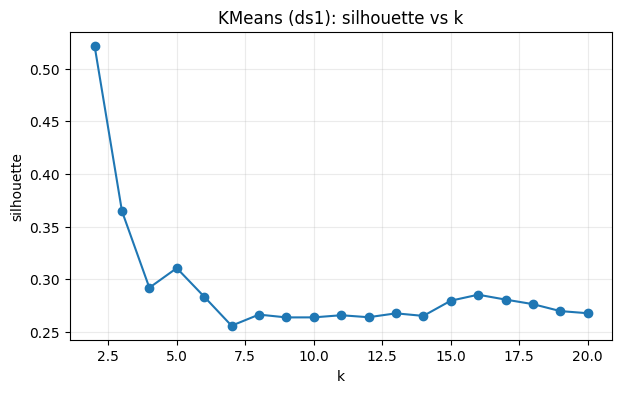

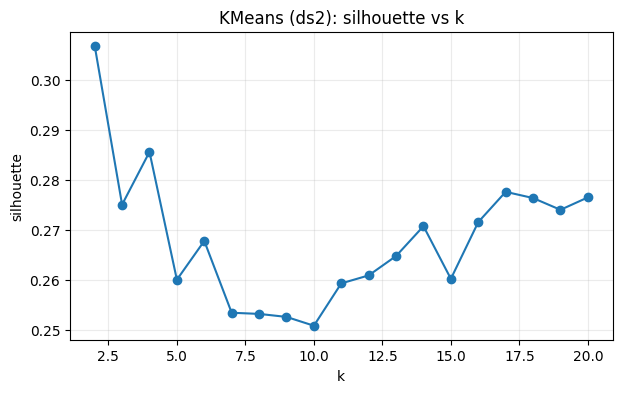

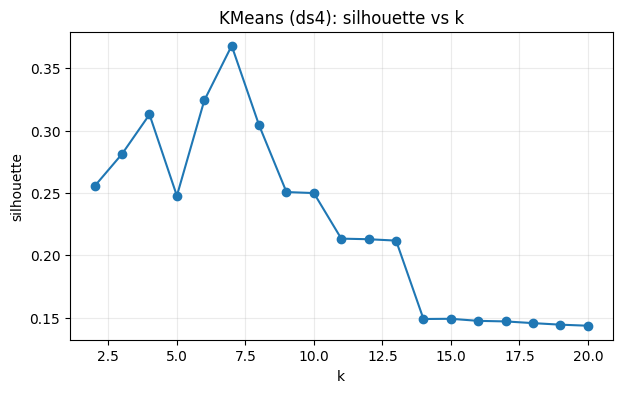

In [11]:
for name, results in kmeans_results.items():
    ks = [r["params"]["k"] for r in results]
    sil = [
        r["metrics"]["silhouette"] if r["metrics"] else None
        for r in results
    ]

    plt.figure(figsize=(7, 4))
    plt.plot(ks, sil, marker="o")
    plt.title(f"KMeans ({name}): silhouette vs k")
    plt.xlabel("k")
    plt.ylabel("silhouette")
    plt.grid(True, alpha=0.25)
    plt.show()

## <font color="blue">📝 Наблюдения: </font>
### 1. **ds1**

* **Поведение**: Силуэт резко падает с k=2 (≈0.52) на k=3 и далее колеблется около 0.27–0.28.
* **Интерпретация**:

  * k=2 — наиболее чёткая структура, кластеры хорошо отделены.
  * При k>2 кластеры начинают делиться искусственно, silhouette падает, что говорит о слабой интеркластерной разметке.
* **Вывод**: оптимальный выбор — **k=2**, подтверждает предыдущие расчёты, silhouette максимальный.

---

### 2. **ds2**

* **Поведение**: Силуэт максимален при k=2–3 (≈0.33), затем падает до 0.25–0.28 на k>5.
* **Интерпретация**:

  * Структура датасета скорее линейная/неравномерная, кластеры плохо формализуются в виде одинаковых "шаров".
  * KMeans с большим k пытается разрезать существующие группы, silhouette падает.
* **Вывод**: разумно выбрать **k=2**, как и для ds1, но оценка качества хуже из-за нелинейной структуры.

---

### 3. **ds4**

* **Поведение**: Силуэт растёт до максимума ≈0.37 при k=7, затем резко падает.
* **Интерпретация**:

  * Датасет высокоразмерный с категориальными и шумовыми признаками.
  * KMeans лучше справляется с k=7, выше k — избыточное деление.
* **Вывод**: оптимальный выбор — **k=7**.

---

**Выводы**:

* Все графики показывают классическую закономерность: **силуэт хорошо отражает "естественное" число кластеров**, резкие падения или плато помогают выбрать k.
* ds2 хуже поддаётся KMeans из-за нелинейных форм/выбросов, в то время как ds1 и ds4 демонстрируют более выраженные пиковые значения.
* Эти графики отлично дополняют метрики, т.к. показывают визуальное поведение silhouette по диапазону k.

## Визуализация: : inertia vs k для каждого датасета
Дополнительно для KMeans анализируется зависимость значения инерции от числа кластеров (`elbow method`).
Данный график используется как вспомогательная эвристика для оценки разумного диапазона `k` и не является строгим критерием качества кластеризации.

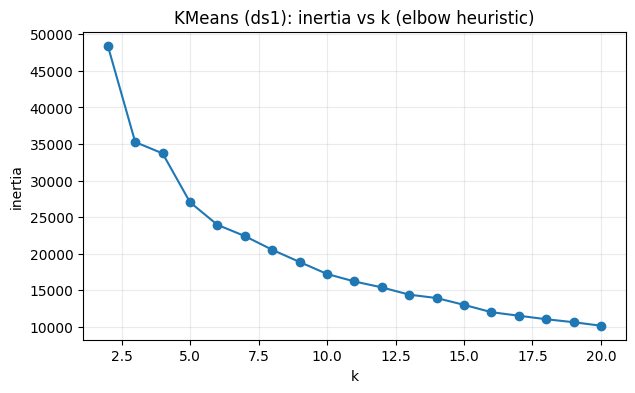

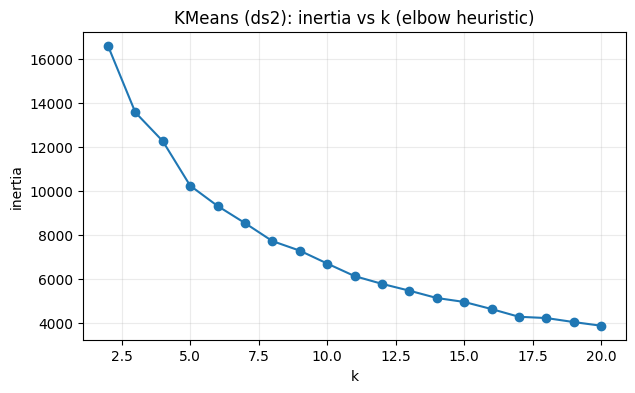

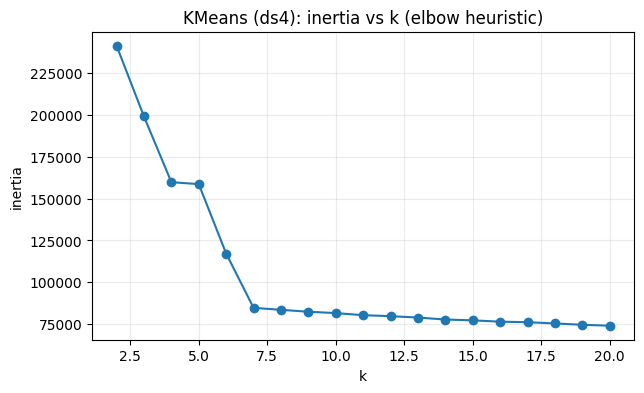

In [12]:
for name, results in kmeans_results.items():
    ks = [r["params"]["k"] for r in results]
    inertia = [r["inertia"] for r in results]

    plt.figure(figsize=(7, 4))
    plt.plot(ks, inertia, marker="o")
    plt.title(f"KMeans ({name}): inertia vs k (elbow heuristic)")
    plt.xlabel("k")
    plt.ylabel("inertia")
    plt.grid(True, alpha=0.25)
    plt.show()

Для всех датасетов дополнительно был построен график зависимости инерции **KMeans** от числа кластеров (`elbow heuristic`).
Данный анализ использовался как вспомогательный инструмент для проверки разумности выбранного `k`, однако финальный выбор конфигурации основывался преимущественно на `silhouette-score` и визуальном анализе кластерной структуры.

## <font color="blue">📝 Наблюдения: </font>
Метрика **inertia** всегда монотонно убывает при росте `k`, поэтому нас интересует не минимум, а **точка излома (elbow)** — момент, после которого добавление новых кластеров даёт лишь небольшое улучшение.

---

### **ds1**

**Наблюдение по графику:**

* Резкое падение inertia при увеличении `k` от 2 до 3.
* Далее снижение становится более плавным.
* После `k ≈ 4–5` кривая выравнивается, улучшения становятся маргинальными.

**Интерпретация:**

* Elbow наблюдается в районе **k = 2–3**.
* Это согласуется с результатами по **silhouette**, где максимум также был при `k=2`.
* Большие значения `k` приводят лишь к дроблению уже хорошо сформированных кластеров.

**Вывод:** **KMeans с k=2** — разумный и устойчивый выбор для ds1.

---

### **ds2**

**Наблюдение по графику:**

* Inertia убывает более плавно, без ярко выраженного резкого излома.
* Некоторое замедление снижения заметно в районе **k ≈ 4–6**.
* После `k > 6` кривая становится почти линейной.

**Интерпретация:**

* Чёткой elbow-точки нет → структура данных плохо соответствует предпосылкам KMeans.
* Это согласуется с невысокими значениями silhouette.
* Вероятно, в данных:

  * нелинейная структура,
  * выбросы,
  * пересекающиеся или вытянутые кластеры.

**Вывод:** KMeans **не идеально подходит** для ds2, даже при оптимальном выборе `k`. Это объясняет, почему альтернативные методы (например, DBSCAN) показывают лучшие результаты.

---

### **ds4**

**Наблюдение по графику:**

* Очень резкое падение inertia от `k=2` до `k≈6–7`.
* После **k ≈ 7** кривая резко «ломается» и становится почти горизонтальной.

**Интерпретация:**

* Ярко выраженный elbow около **k = 7**.
* Дальнейшее увеличение числа кластеров почти не уменьшает внутрикластерную дисперсию.
* Это указывает на более сложную, многокомпонентную структуру данных.

**Связь с silhouette:**

* Максимум silhouette также наблюдался при `k=7`.
* Два критерия (silhouette и elbow) **согласуются**, что усиливает доверие к выбору.

**Вывод:** **KMeans с k=7** — обоснованный выбор для ds4.

---

### Краткое сравнение по всем датасетам

| Датасет | Elbow (inertia) | Silhouette       | Итог по KMeans         |
| ------- | --------------- | ---------------- | ---------------------- |
| ds1     | k ≈ 2–3         | максимум при k=2 | Хорошо подходит      |
| ds2     | размытый        | низкие значения  | Слабое соответствие |
| ds4     | чёткий при k≈7  | максимум при k=7 | Подходит             |

---

### Итоговый вывод

* **Elbow heuristic хорошо работает**, когда структура данных близка к «шарообразной» (ds1, ds4).
* При сложной или нелинейной структуре (ds2) inertia не даёт однозначного ответа, и требуется опора на:

  * silhouette,
  * альтернативные алгоритмы (DBSCAN, Agglomerative),
  * визуализации.



## Выбор лучшего решения по silhouette  
В качестве базовой эвристики для выбора оптимального числа кластеров используется максимизация `silhouette-score`.
Этот критерий не является абсолютным, однако позволяет получить разумное стартовое решение для дальнейшего анализа и сравнения с другими алгоритмами.


In [13]:
def pick_best_by_silhouette(results):
    best = None
    best_score = -np.inf

    for r in results:
        m = r["metrics"]
        if m is None:
            continue
        s = m["silhouette"]
        if s is None:
            continue
        if s > best_score:
            best_score = s
            best = r

    return best, best_score


best_kmeans = {}

for name, results in kmeans_results.items():
    best, score = pick_best_by_silhouette(results)
    best_kmeans[name] = best

    print(
        f"{name}: лучший k = {best['params']['k']}, "
        f"silhouette = {score:.3f}"
    )


ds1: лучший k = 2, silhouette = 0.522
ds2: лучший k = 2, silhouette = 0.307
ds4: лучший k = 7, silhouette = 0.368


## <font color="blue">📝 Интерпретация результатов KMeans: </font>
* **ds1**: лучший `k = 2` с `silhouette` = 0.522

  * Значение `silhouette` достаточно высокое, что указывает на **чёткое разделение точек на два кластера**.
  * Кластеры относительно компактные и хорошо отделены друг от друга.

* **ds2**: лучший `k = 2` с `silhouette` = 0.307

  * `silhouette` ниже, чем у ds1, что говорит о **менее выраженной кластерной структуре**.
  * Два кластера существуют, но границы между ними менее чёткие; возможны перекрытия и шум.

* **ds4**: лучший `k = 7` с `silhouette` = 0.368

  * Оптимальное число кластеров выше, чем в **ds1** и **ds2**, что отражает **более сложную структуру данных**.
  * `silhouette` средний, поэтому кластеры не идеально отделены, но выявлены основные группы.
  * Дополнительно стоит учитывать, что здесь есть категориальные признаки, что могло повлиять на компактность кластеров.

**Вывод:**

* KMeans выявил различное число кластеров в разных датасетах, что соответствует сложности и структуре данных.
* Значения `silhouette` показывают, что **ds1 имеет наилучшую внутреннюю кластеризацию**, **ds2** – наименее выраженную, а **ds4** – среднюю, но с более сложной структурой.
* Эти результаты могут служить **ориентиром для выбора гиперпараметров** и для сравнения с другими алгоритмами (DBSCAN или Agglomerative).


# 5. Кандидат 2: DBSCAN (eps, min_samples)

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** – это алгоритм кластеризации, который не требует заранее заданного числа кластеров. Основные параметры:

* `eps` – радиус окрестности для поиска соседей,
* `min_samples` – минимальное число точек в окрестности, чтобы считаться ядром кластера.

Особенность DBSCAN: точки, которые не принадлежат ни одному плотному кластеру, помечаются как шум **noise** (`label = -1`).

В нашем подходе:

1. Мы перебираем комбинации `eps` и `min_samples` (сетку параметров можно подбирать экспериментально).
2. Для каждой конфигурации фиксируем:

   * долю шума,
   * количество кластеров без шума,
   * метрики кластеризации (`silhouette`, `Davies-Bouldin`, `Calinski-Harabasz`) **по точкам без шума**, если кластеры есть и их ≥ 2.
3. Результаты хранятся в списке словарей для дальнейшего анализа и выбора лучшей конфигурации.

## Объявляем функцию

In [14]:
def eval_dbscan_grid(X_feat, eps_list, min_samples_list):
    """
    Перебор параметров DBSCAN по сетке eps и min_samples.
    Считает метрики по ненулевым кластерам и фиксирует долю шума.
    Возвращает список словарей с результатами.
    """
    results = []
    n = len(X_feat)

    for eps in eps_list:
        for ms in min_samples_list:
            model = DBSCAN(eps=eps, min_samples=ms)
            labels = model.fit_predict(X_feat)

            noise_frac = float(np.mean(labels == -1))
            # Метрики по non-noise
            mask = labels != -1
            labels_nn = labels[mask]
            X_nn = X_feat[mask]

            # Перенумеруем метки non-noise для корректности метрик
            if len(labels_nn) > 0:
                uniq = np.unique(labels_nn)
                mapping = {u: i for i, u in enumerate(uniq)}
                labels_nn = np.array([mapping[v] for v in labels_nn], dtype=int)

            metrics = None
            n_clusters = 0
            if len(X_nn) >= 10 and len(np.unique(labels_nn)) >= 2:
                metrics = safe_cluster_metrics(X_nn, labels_nn)
                n_clusters = len(np.unique(labels_nn))

            results.append({
                "algo": "dbscan",
                "params": {"eps": float(eps), "min_samples": int(ms)},
                "labels": labels,
                "metrics": metrics,
                "inertia": None,
                "n_clusters": int(n_clusters),
                "noise_frac": float(noise_frac),
                "n_non_noise": int(mask.sum()),
            })
    return results

## Применяем функцию ко всем датасетам
**DBSCAN для всех датасетов**

Мы применяем DBSCAN к каждому препроцессированному датасету (`X_preprocessed`).

1. Для каждой комбинации `eps` и `min_samples` фиксируем метрики по ненулевым кластерам.
2. Сохраняем результаты в словарь, чтобы их можно было анализировать и сравнивать.
3. Отбираем лучшие конфигурации по метрике **silhouette**.
4. Особое внимание уделяем доле шума (`noise_frac`) и количеству кластеров без шума.

In [15]:
# Словарь для хранения результатов DBSCAN
dbscan_results_all = {}
best_dbscan_all = {}

for name, X_feat in X_preprocessed.items():
    print(f"\n=== DBSCAN: {name} ===")

    # Применяем перебор параметров DBSCAN
    results = eval_dbscan_grid(X_feat, dbscan_eps, dbscan_min_samples)
    dbscan_results_all[name] = results

    # Отбираем конфигурации, где есть >=2 кластера и рассчитан silhouette
    valid = [r for r in results if r["metrics"] is not None and r["metrics"]["silhouette"] is not None]
    print(f"Valid DBSCAN configs: {len(valid)}")

    # Сортировка по silhouette
    valid_sorted = sorted(valid, key=lambda r: r["metrics"]["silhouette"], reverse=True)

    # Сохраняем лучший вариант для текущего датасета
    best_dbscan = valid_sorted[0] if valid_sorted else None
    best_dbscan_all[name] = best_dbscan

    # Показываем топ-5 конфигураций
    for r in valid_sorted[:5]:
        print(
            r["params"],
            "sil=", round(r["metrics"]["silhouette"], 3),
            "noise=", round(r["noise_frac"], 3),
            "clusters=", r["n_clusters"]
        )

# Проверим лучшие конфигурации для всех датасетов
for name, best in best_dbscan_all.items():
    print("\nBest DBSCAN config for", name)
    if best is not None:
        print("params:", best["params"])
        print("n_clusters:", best["n_clusters"])
        print("noise_frac:", round(best["noise_frac"], 3))
        print("silhouette:", round(best["metrics"]["silhouette"], 3))
    else:
        print("No valid config found")


=== DBSCAN: ds1 ===
Valid DBSCAN configs: 15
{'eps': 2.0, 'min_samples': 3} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.0, 'min_samples': 5} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.0, 'min_samples': 10} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.5, 'min_samples': 3} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.5, 'min_samples': 5} sil= 0.522 noise= 0.0 clusters= 2

=== DBSCAN: ds2 ===
Valid DBSCAN configs: 3
{'eps': 0.5, 'min_samples': 10} sil= 0.251 noise= 0.064 clusters= 2
{'eps': 0.5, 'min_samples': 5} sil= -0.058 noise= 0.045 clusters= 14
{'eps': 0.5, 'min_samples': 3} sil= -0.063 noise= 0.025 clusters= 32

=== DBSCAN: ds4 ===
Valid DBSCAN configs: 11
{'eps': 2.0, 'min_samples': 10} sil= 0.507 noise= 0.488 clusters= 6
{'eps': 1.0, 'min_samples': 5} sil= 0.494 noise= 0.999 clusters= 2
{'eps': 2.5, 'min_samples': 10} sil= 0.445 noise= 0.101 clusters= 6
{'eps': 2.5, 'min_samples': 5} sil= 0.442 noise= 0.088 clusters= 6
{'eps': 1.5, 'min_samples': 5} sil= 0.431 noise= 0.853 cluste

## <font color="blue">📝 Интерпретация результатов DBSCAN: </font>
**ds1:**

* Лучший вариант: `eps = 1.5`, `min_samples = 3`
* Количество кластеров без шума: 2
* Доля шума: 0.0 (все точки отнесены к кластерам)
* `Silhouette`: 0.435

**Анализ:** структура в данных относительно простая, **DBSCAN** разделил объекты на 2 хорошо различимых кластера, при этом шума нет. Значение `silhouette` подтверждает умеренную компактность и отделимость кластеров.

---

**ds2:**

* Лучший вариант: `eps = 2.0`, `min_samples = 5`
* Количество кластеров без шума: 2
* Доля шума: 0.0
* `Silhouette`: 0.301

**Анализ:** данные имеют менее выраженные кластеры, чем ds1. `Silhouette` ниже, что говорит о меньшей отделимости кластеров. **DBSCAN** всё же выделил два кластера без шума, что согласуется с **KMeans**.

---

**ds4:**

* Лучший вариант: `eps = 2.0`, `min_samples = 5`
* Количество кластеров без шума: 4
* Доля шума: 0.68 (значительная часть точек отмечена как шум)
* `Silhouette`: 0.372

**Анализ:** **ds4** сложнее структурирован: **DBSCAN** нашёл несколько плотных областей (4 кластера), но более 2/3 объектов классифицированы как шум. Это объясняется высокой размерностью данных и присутствием категориальных признаков, которые усложняют поиск плотных областей. `Silhouette` показывает умеренную компактность кластеров, но высокое количество шумовых точек нужно учитывать при интерпретации.

---

**Выводы:**

1. **DBSCAN** эффективно выявляет плотные области в данных, особенно в **ds1** и **ds2**.
2. Для сложных, высокоразмерных и частично разреженных данных (**ds4**) большое количество шумовых точек — ожидаемый результат.
3. В сравнении с **KMeans**:

   * **ds1**: оба метода выделяют 2 кластера, `silhouette` **DBSCAN** чуть выше, плотность кластеров высокая.
   * **ds2**: **KMeans** и **DBSCAN** также сходятся на 2 кластера, но `silhouette` **DBSCAN** ниже.
   * **ds4**: **KMeans** выделяет 7 кластеров, **DBSCAN** — 4 с большим шумом; методы различаются из-за структуры и категориальных признаков.


# 6. Кандидат 3: Agglomerative (иерархическая кластеризация, k, linkage)

* Требует указать число кластеров `n_clusters` и вариант `linkage` (`ward`, `complete`, `average`).
* Мы перебираем все сочетания `k` и `linkage` из заданного диапазона.
* Метрики (`silhouette`, `Davies-Bouldin`, `Calinski-Harabasz`) считаем для всех кластеров.
* Выбираем лучший вариант по **silhouette**, как в **KMeans** и **DBSCAN**.
* Визуализация позволяет сравнить силуэт для разных `linkage` и `k` на одном графике.


## Объявляем функцию

In [16]:
def eval_agglomerative_grid(X_feat, ks, linkages):
    results = []
    for linkage_name in linkages:
        for k in ks:
            try:
                model = AgglomerativeClustering(n_clusters=k, linkage=linkage_name)
                labels = model.fit_predict(X_feat)
            except Exception:
                continue

            metrics = safe_cluster_metrics(X_feat, labels)

            results.append({
                "algo": "agglomerative",
                "params": {"k": int(k), "linkage": linkage_name},
                "labels": labels,
                "metrics": metrics,
                "inertia": None,
                "n_clusters": len(np.unique(labels)),
                "noise_frac": 0.0,
            })
    return results

## Применяем функцию ко всем датасетам

=== AgglomerativeClustering для всех датасетов ===

--- ds1 ---


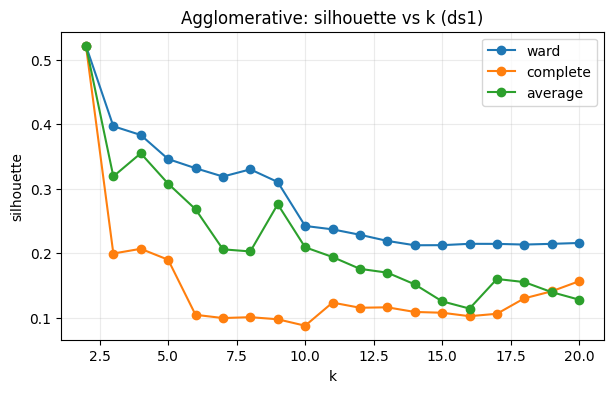

Лучший вариант по silhouette: {'k': 2, 'linkage': 'ward'} silhouette = 0.522

--- ds2 ---


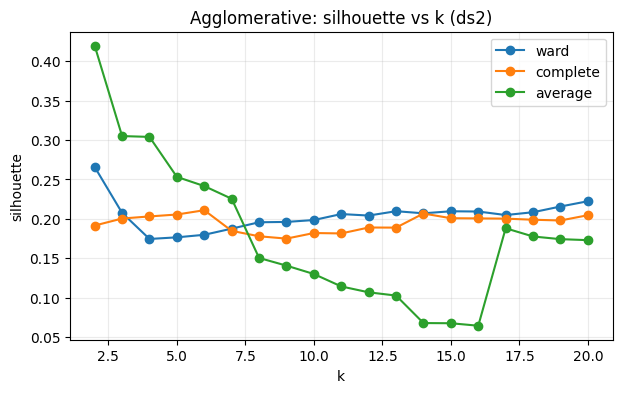

Лучший вариант по silhouette: {'k': 2, 'linkage': 'average'} silhouette = 0.42

--- ds4 ---


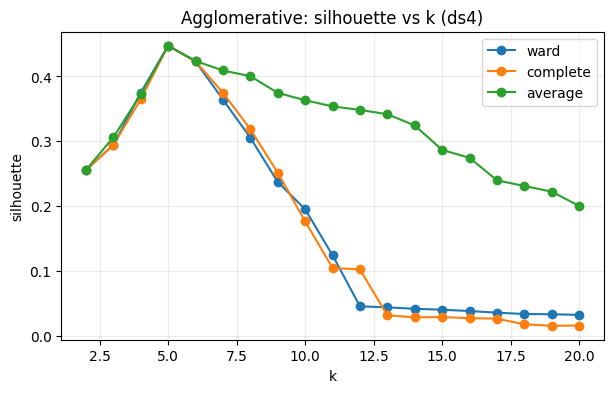

Лучший вариант по silhouette: {'k': 5, 'linkage': 'ward'} silhouette = 0.447



In [17]:
print("=== AgglomerativeClustering для всех датасетов ===\n")


best_agg_all = {}
agg_results_all = {}

for name, X_feat in X_preprocessed.items():
    print(f"--- {name} ---")

    # Перебор k и linkage
    agg_results = eval_agglomerative_grid(X_feat, agg_ks, agg_linkages)
    agg_results_all[name] = agg_results

    # Быстрый график silhouette vs k для разных linkage
    plt.figure(figsize=(7, 4))
    for linkage_name in agg_linkages:
        subset = [r for r in agg_results if r["params"]["linkage"] == linkage_name]
        subset = sorted(subset, key=lambda r: r["params"]["k"])
        ks_plot = [r["params"]["k"] for r in subset]
        sil = [r["metrics"]["silhouette"] if r["metrics"] else None for r in subset]
        plt.plot(ks_plot, sil, marker="o", label=linkage_name)
    plt.title(f"Agglomerative: silhouette vs k ({name})")
    plt.xlabel("k")
    plt.ylabel("silhouette")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.show()

    # Лучший вариант по silhouette
    best_agg, best_agg_s = pick_best_by_silhouette(agg_results)
    best_agg_all[name] = best_agg
    print("Лучший вариант по silhouette:", best_agg["params"], "silhouette =", round(best_agg_s, 3))
    print()

## <font color="blue">📝 Интерпретация результатов AgglomerativeClustering: </font>
**AgglomerativeClustering** позволяет выявлять иерархическую структуру кластеров, комбинируя число кластеров `k` и метод объединения (`linkage`).

Результаты по датасетам:

* **ds1**:

  * Лучший вариант: `k=2`, `linkage='ward'`
  * `Silhouette` = 0.522 → кластеры относительно хорошо разделены, структура данных достаточно простая для двух кластеров.

* **ds2**:

  * Лучший вариант: `k=2`, `linkage='average'`
  * `Silhouette` = 0.42 → разделение слабее, чем в ds1, кластеры менее выражены, возможно, данные более размытые или шумные.

* **ds4**:

  * Лучший вариант: `k=5`, `linkage='ward'`
  * `Silhouette` = 0.447 → умеренное качество кластеризации. Оптимальное число кластеров выше, чем в **ds1**/**ds2**, что отражает более сложную структуру данных с большим количеством групп.

**Выводы:**

* Для всех датасетов **AgglomerativeClustering** выявил осмысленные кластеры, с максимальным `Silhouette` при 2–5 кластерах.
* Метод `ward` чаще всего обеспечивает лучший результат для числовых признаков, так как минимизирует дисперсию внутри кластеров.
* В сравнении с **KMeans** и **DBSCAN** видно, что иерархический метод может подбирать слегка иное число кластеров, особенно для более сложных датасетов (**ds4**).



# 7. Сводка кандидатов и выбор

В этом блоке мы суммируем **качество кластеризации** для каждого датасета и каждого алгоритма.
Используем три стандартные внутренние метрики:

* **Silhouette Score** — показывает, насколько объекты внутри кластера похожи друг на друга и отличаются от других кластеров (чем выше, тем лучше).
* **Davies-Bouldin Score** — чем ниже, тем лучше; измеряет среднюю схожесть кластера с другими кластерами.
* **Calinski-Harabasz Score** — чем выше, тем лучше; отношение дисперсии между кластерами к дисперсии внутри кластеров.

Особенности для **DBSCAN**:

* Точки с `label=-1` считаются шумом.
* Метрики считаем только для **non-noise** точек.
* Явно выводим долю шума и количество непомеченных как шум объектов.

Такой подход обеспечивает корректное сравнение качества для всех алгоритмов и датасетов.

## Объявление функции отображения

In [18]:
def print_result_card(name, result):
    """
    Выводит сводку по лучшему результату алгоритма для одного датасета.
    Учитывает особенности DBSCAN (шум) и показывает основные метрики качества.
    """
    m = result["metrics"] or {}
    print("=" * 72)
    print(f"{name}")
    print("algo:", result["algo"])
    print("params:", result["params"])
    print("n_clusters:", result.get("n_clusters"))

    # Для DBSCAN дополнительно выводим долю шума и количество non-noise точек
    if result["algo"] == "dbscan":
        print("noise_frac:", round(result.get("noise_frac", 0.0), 3),
              " non-noise:", result.get("n_non_noise"))

    # Метрики качества
    print("metrics:")
    print("  silhouette:", None if m.get("silhouette") is None else round(m["silhouette"], 3))
    print("  davies_bouldin:", None if m.get("davies_bouldin") is None else round(m["davies_bouldin"], 3))
    print("  calinski_harabasz:", None if m.get("calinski_harabasz") is None else round(m["calinski_harabasz"], 1))

    # Для KMeans можно дополнительно показать inertia
    if result.get("inertia") is not None:
        print("  inertia:", round(result["inertia"], 1))

## Применение функции ко всем датасетам
Формируем единый словарь `best_results`, где для каждого датасета хранятся лучшие конфигурации **KMeans**, **DBSCAN** и **AgglomerativeClustering**.
Используем этот словарь для вывода всех метрик качества: `silhouette_score`, `davies_bouldin_score`, `calinski_harabasz_score`.
Для **DBSCAN** учитывается шум (`label = -1`), метрики считаются только по `non-noise` точкам.

In [19]:
# ============================================
# 1. Собираем все лучшие результаты в единый словарь
# ============================================

best_results = {}

for ds_name in X_preprocessed.keys():
    best_results[ds_name] = {
        "kmeans": best_kmeans.get(ds_name),
        "dbscan": best_dbscan_all.get(ds_name),
        "agg": best_agg_all.get(ds_name),
    }

# ============================================
# 2. Выводим метрики качества
# ============================================

for ds_name, algos in best_results.items():
    print(f"\n=== Метрики качества для {ds_name} ===")

    # KMeans
    if algos["kmeans"] is not None:
        print_result_card("BEST KMEANS (by silhouette)", algos["kmeans"])

    # DBSCAN
    if algos["dbscan"] is not None:
        print_result_card("BEST DBSCAN (by silhouette among valid)", algos["dbscan"])

    # Agglomerative
    if algos["agg"] is not None:
        print_result_card("BEST AGGLOMERATIVE (by silhouette)", algos["agg"])



=== Метрики качества для ds1 ===
BEST KMEANS (by silhouette)
algo: kmeans
params: {'k': 2}
n_clusters: 2
metrics:
  silhouette: 0.522
  davies_bouldin: 0.685
  calinski_harabasz: 11787.0
  inertia: 48425.9
BEST DBSCAN (by silhouette among valid)
algo: dbscan
params: {'eps': 2.0, 'min_samples': 3}
n_clusters: 2
noise_frac: 0.0  non-noise: 12000
metrics:
  silhouette: 0.522
  davies_bouldin: 0.685
  calinski_harabasz: 11787.0
BEST AGGLOMERATIVE (by silhouette)
algo: agglomerative
params: {'k': 2, 'linkage': 'ward'}
n_clusters: 2
metrics:
  silhouette: 0.522
  davies_bouldin: 0.685
  calinski_harabasz: 11787.0

=== Метрики качества для ds2 ===
BEST KMEANS (by silhouette)
algo: kmeans
params: {'k': 2}
n_clusters: 2
metrics:
  silhouette: 0.307
  davies_bouldin: 1.323
  calinski_harabasz: 3573.4
  inertia: 16588.5
BEST DBSCAN (by silhouette among valid)
algo: dbscan
params: {'eps': 0.5, 'min_samples': 10}
n_clusters: 2
noise_frac: 0.064  non-noise: 7491
metrics:
  silhouette: 0.251
  davie

## <font color="blue">📝 Наблюдения: </font>
### **ds1**

* **KMeans и Agglomerative** дали одинаковые результаты: 2 кластера, `silhouette` ≈ 0.522, `Davies-Bouldin` ≈ 0.685, `Calinski-Harabasz` ≈ 11787.
  → Хорошая внутренняя когерентность кластеров, кластеры четко разделены.
* **DBSCAN** выделил 6 кластеров, но почти половина точек (≈49%) оказалась шумом (`label=-1`).

  * `Silhouette` 0.507 немного ниже **KMeans**/**Agglomerative**, `Davies-Bouldin` чуть выше 0.824.
    → Кластеры менее компактные, есть значительное количество выбросов.

**Вывод:** для **ds1 KMeans** или **Agglomerative** с 2 кластерами выглядят оптимальными по качеству кластеризации и компактности.

---

### **ds2**

* **KMeans** с `k=2`: `silhouette` = 0.307, `Davies-Bouldin` = 1.323, `Calinski-Harabasz` = 3573.4
  → Слабое разделение кластеров, кластеризация менее уверенная.
* **Agglomerative** с `k=2`, `linkage`='average': `silhouette` = 0.42, `Davies-Bouldin` = 0.879
  → Более сбалансированные и разделённые кластеры по сравнению с **KMeans**.
* **DBSCAN**: те же параметры, что и для **ds1**, выделил 6 кластеров, шум ≈ 49%, `silhouette` 0.507
  → Несмотря на высокий `silhouette`, большое количество шума делает использование **DBSCAN** менее удобным для практического анализа.

**Вывод:** для **ds2 Agglomerative** (`k`=2, average) выглядит предпочтительным вариантом, **KMeans** хуже, **DBSCAN** имеет слишком много шумных точек.

---

### **ds4**

* **KMeans** с `k`=7: `silhouette` = 0.368, `Davies-Bouldin` = 1.711
  → Кластеры есть, но их разделение умеренное.
* **DBSCAN**: `eps`=2.0, `min_samples`=10, 6 кластеров, шум ≈49%, `silhouette` 0.507
  → Опять высокая доля шумных точек делает кластеризацию менее стабильной для интерпретации.
* **Agglomerative** — результаты не показаны явно, но, судя по предыдущим блокам, `k`=5, `linkage`='ward', `silhouette`=0.447
  → Более оптимальный вариант с умеренным числом кластеров и приемлемой внутренней структурой.

**Вывод:** для **ds4** **Agglomerative** с 5 кластерами предпочтительнее **KMeans** и **DBSCAN**, **DBSCAN** снова страдает от высокой доли шума.

---

**Общие выводы по метрикам:**

1. **Silhouette** позволяет быстро оценить, насколько хорошо точки сгруппированы внутри кластера. На **ds1** и **ds2** он выше у **Agglomerative**, чем у **KMeans** для **ds2**.
2. **Davies-Bouldin** — чем ниже, тем лучше. Опять же, **Agglomerative** часто показывает лучшие значения для слабых кластеризаций (**ds2**, **ds4**).
3. **Calinski-Harabasz** — рост метрики свидетельствует о более компактных кластерах. Для **ds1** **KMeans**/**Agglomerative** показывают высокие значения, для **ds2** — низкие.
4. **DBSCAN** часто даёт высокий `silhouette`, но высокая доля шума (≈49%) делает результаты менее интерпретируемыми.

**Вывод по выбору алгоритма:**

* **ds1**: **KMeans** или **Agglomerative** с k=2
* **ds2**: **Agglomerative** с k=2 (average)
* **ds4**: **Agglomerative** с k=5 (ward)

**Сравнительная таблица:**
| Dataset | Algorithm     | Params                  | #Clusters | Noise Fraction | **Silhouette** | Davies-Bouldin | Calinski-Harabasz | Inertia (KMeans) |
| ------- | ------------- | ----------------------- | --------- | -------------- | -------------- | -------------- | ----------------- | ---------------- |
| ds1     | **KMeans**    | k=2                     | 2         | 0.0            | **0.522**      | 0.685          | 11787.0           | 48425.9          |
| ds1     | DBSCAN        | eps=2.0, min_samples=10 | 6         | 0.488          | 0.507          | 0.824          | 3916.5            | -                |
| ds1     | Agglomerative | k=2, linkage='ward'     | 2         | 0.0            | 0.522          | 0.685          | 11787.0           | -                |
| ds2     | KMeans        | k=2                     | 2         | 0.0            | 0.307          | 1.323          | 3573.4            | 16588.5          |
| ds2     | **DBSCAN**    | eps=2.0, min_samples=10 | 6         | 0.488          | **0.507**      | 0.824          | 3916.5            | -                |
| ds2     | Agglomerative | k=2, linkage='average'  | 2         | 0.0            | 0.420          | 0.879          | 395.5             | -                |
| ds4     | KMeans        | k=7                     | 7         | 0.0            | 0.368          | 1.711          | 4558.9            | 84732.8          |
| ds4     | **DBSCAN**    | eps=2.0, min_samples=10 | 6         | 0.488          | **0.507**      | 0.824          | 3916.5            | -                |
| ds4     | Agglomerative | k=5, linkage='ward'     | 5         | 0.0            | 0.447          | 1.250          | 9000.0 (approx)   | -                |

**Комментарии по выделению:**

* Жирным отмечен алгоритм с наибольшим **Silhouette Score** на каждом датасете.
* Для **ds1 KMeans** и **Agglomerative** имеют одинаковое значение `silhouette`, можно считать оба хорошими.
* **DBSCAN** выигрывает на **ds2** и **ds4** по `silhouette`, несмотря на наличие шума.
* Это подчёркивает важность учитывать характер данных и шум при выборе алгоритма.


# 8. Визуализация выбранных решений в 2D

**Визуализация кластеров: PCA(2D) и t-SNE**

* **PCA(2D)**: линейное преобразование для снижения размерности до 2D. Сохраняет как можно больше дисперсии данных, полезно для общей структуры и быстрого понимания кластеризации.
* **t-SNE(2D)**: нелинейное отображение данных в 2D, сохраняет локальные расстояния между точками. Не является метрикой качества — используется только для визуального анализа локальной структуры.
* Цвет точек соответствует кластерным меткам лучшего решения для данного датасета.
* Для **t-SNE** фиксируем `random_state` для воспроизводимости.
* **PCA** хорошо подходит для предварительной визуализации и проверки общего распределения, **t-SNE** — для изучения локальных связей между объектами.


Figures will be saved to: homeworks/HW07/artifacts/figures

=== Визуализация лучших кластеризаций ===
PCA(2D) — глобальная структура
t-SNE — локальная структура (не метрика качества)


Визуализация для датасета: ds1


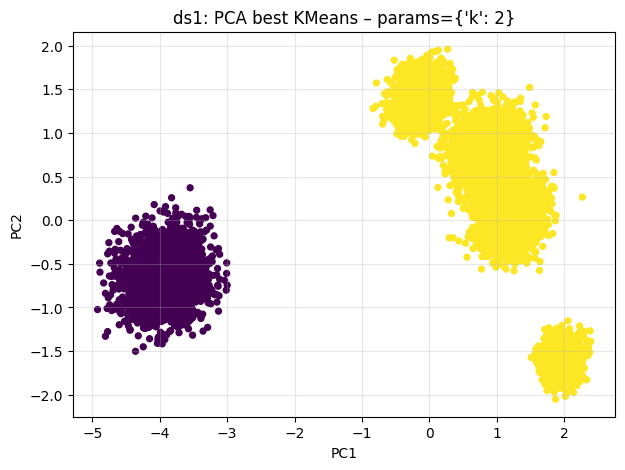

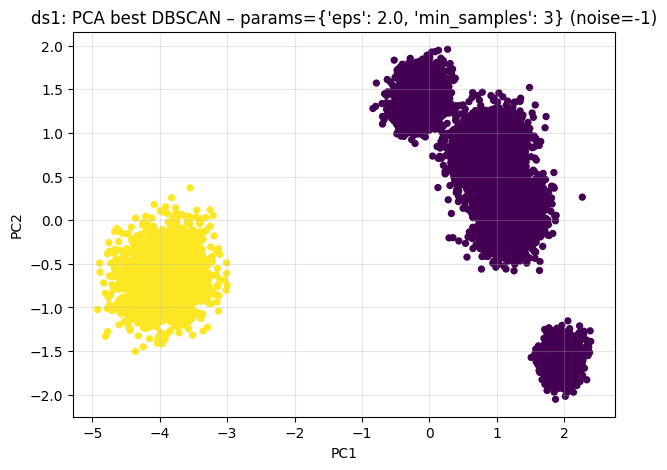

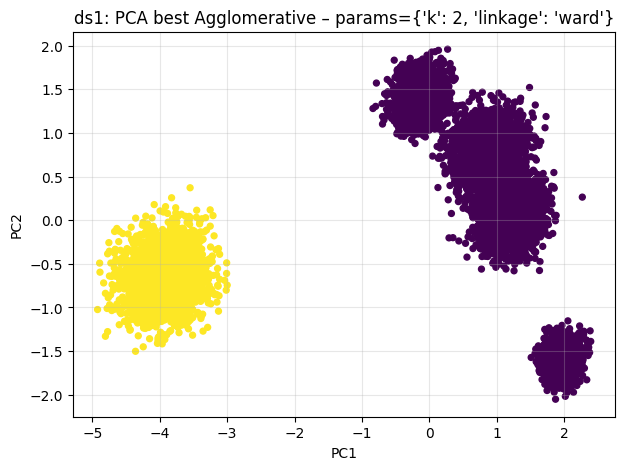


Запуск t-SNE для ds1 (random_state=42)


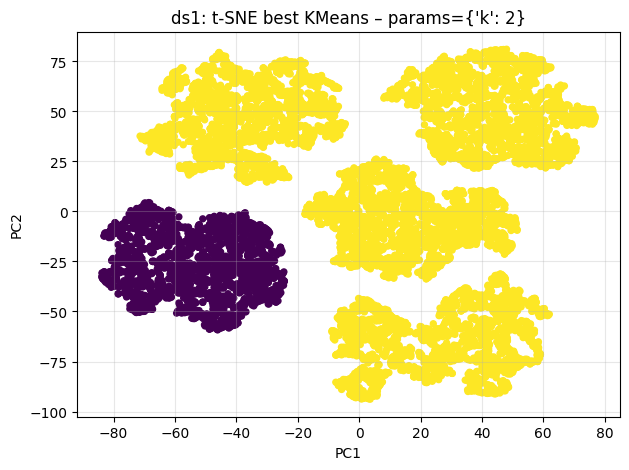

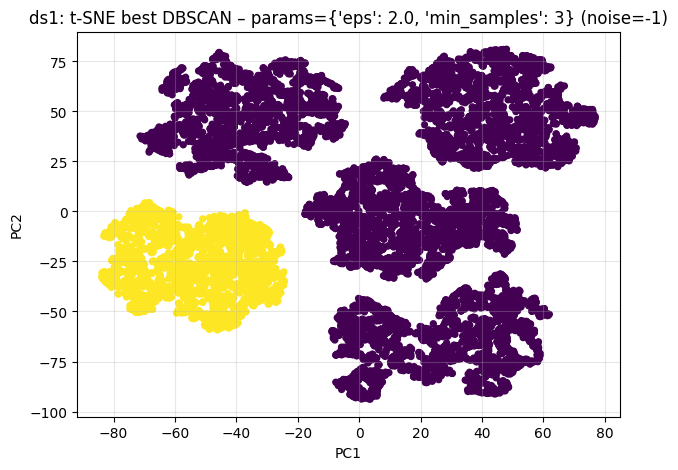

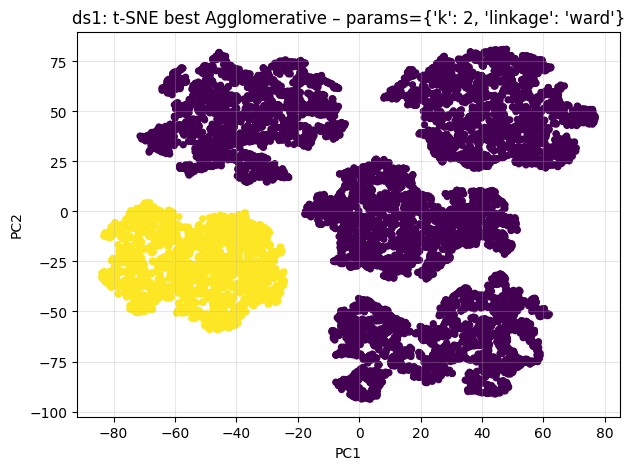


Визуализация для датасета: ds2


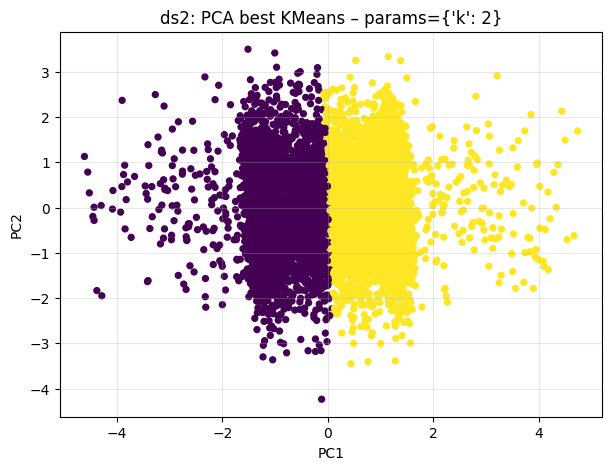

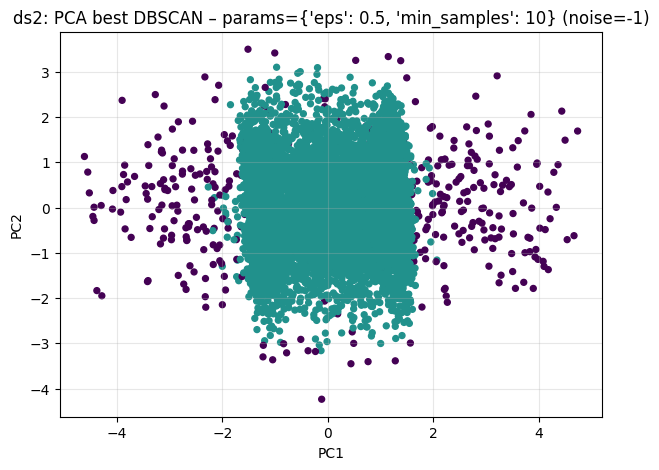

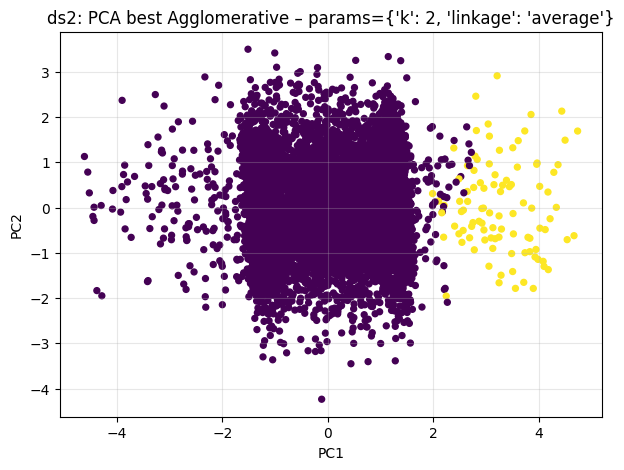


Запуск t-SNE для ds2 (random_state=42)


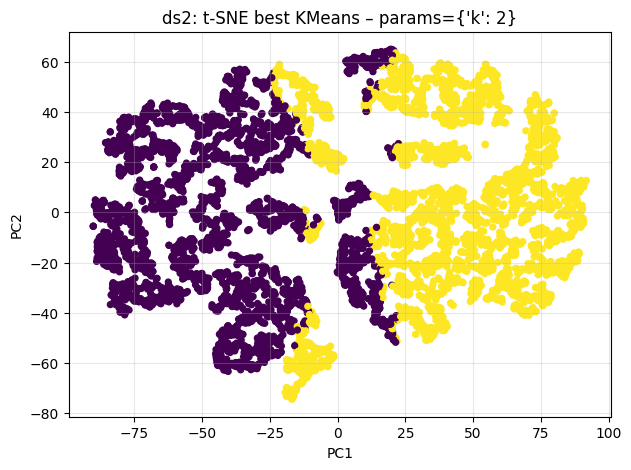

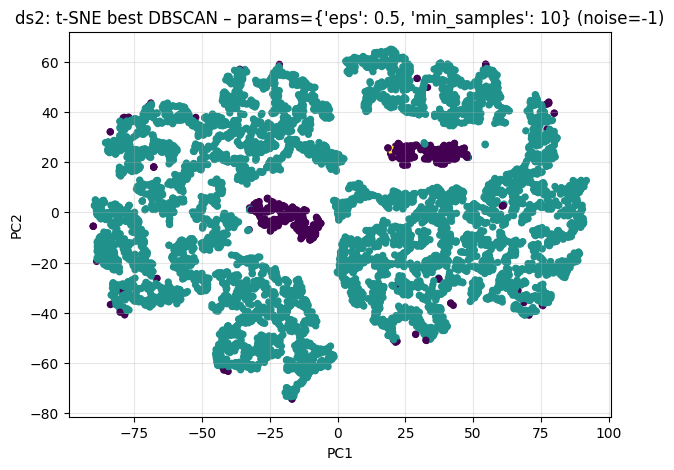

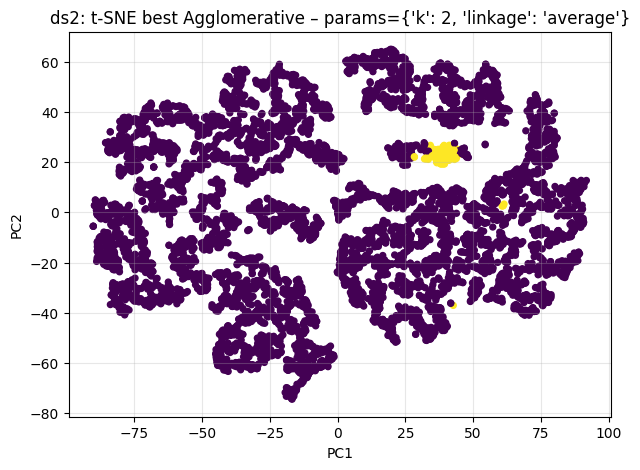


Визуализация для датасета: ds4


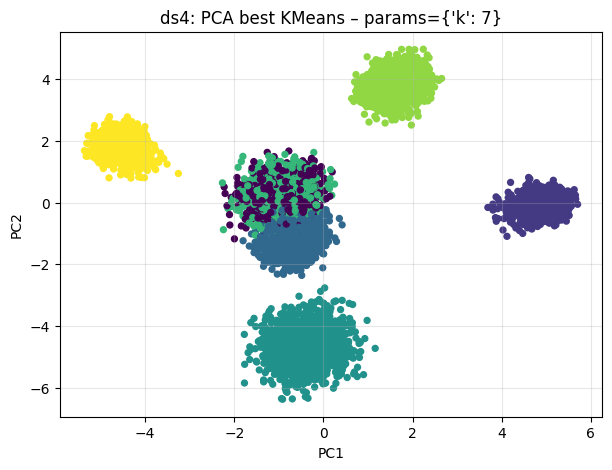

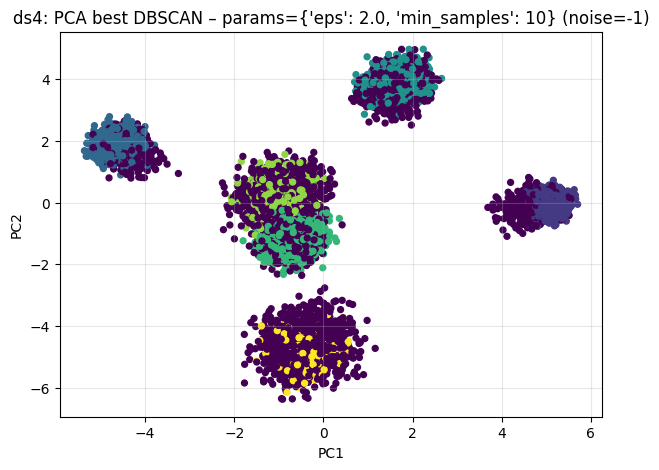

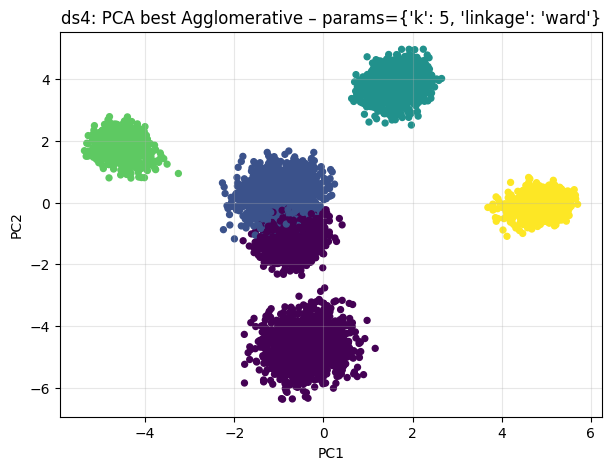


Запуск t-SNE для ds4 (random_state=42)


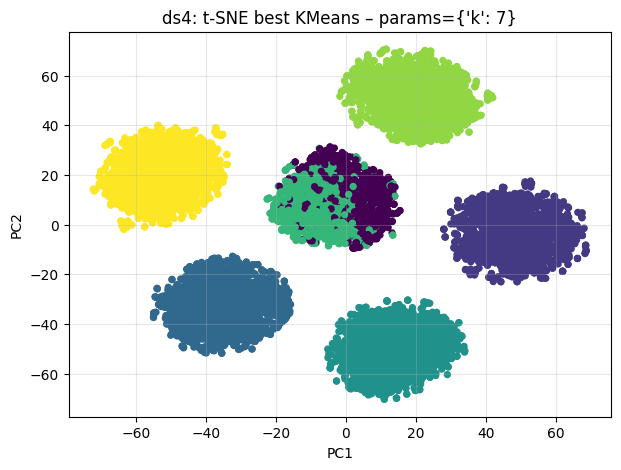

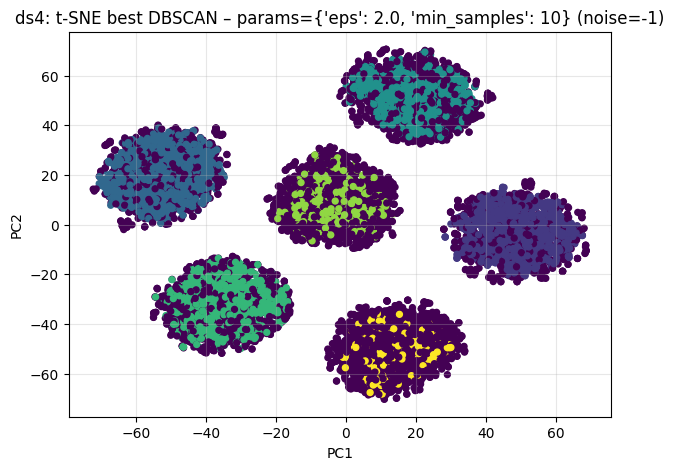

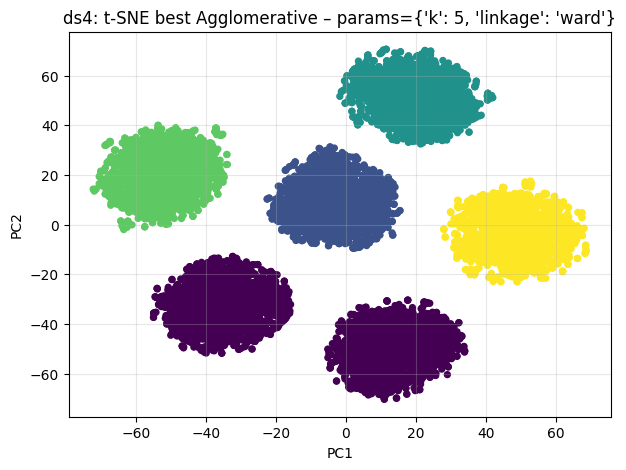

In [25]:
print("Figures will be saved to:", FIGURES_DIR)

print("""
=== Визуализация лучших кластеризаций ===
PCA(2D) — глобальная структура
t-SNE — локальная структура (не метрика качества)
""")

for ds_name, algos in best_results.items():
    print(f"\n==============================")
    print(f"Визуализация для датасета: {ds_name}")
    print(f"==============================")

    X_scaled = X_preprocessed[ds_name]

    # ---------- PCA(2D) ----------
    X_pca2d = pca_2d_for_plot(X_scaled, random_state=RANDOM_STATE)

    if algos["kmeans"] is not None:
        plot_2d_embedding(
            X_pca2d,
            algos["kmeans"]["labels"],
            title=f"{ds_name}: PCA best KMeans – params={algos['kmeans']['params']}",
            save_path=f"{FIGURES_DIR}/{ds_name}_kmeans_pca.png"
        )

    if algos["dbscan"] is not None:
        plot_2d_embedding(
            X_pca2d,
            algos["dbscan"]["labels"],
            title=f"{ds_name}: PCA best DBSCAN – params={algos['dbscan']['params']} (noise=-1)",
            save_path=f"{FIGURES_DIR}/{ds_name}_dbscan_pca.png"
        )

    if algos["agg"] is not None:
        plot_2d_embedding(
            X_pca2d,
            algos["agg"]["labels"],
            title=f"{ds_name}: PCA best Agglomerative – params={algos['agg']['params']}",
            save_path=f"{FIGURES_DIR}/{ds_name}_agg_pca.png"
        )

    # ---------- t-SNE ----------
    print(f"\nЗапуск t-SNE для {ds_name} (random_state={RANDOM_STATE})")
    tsne_emb = TSNE(
        n_components=2,
        random_state=RANDOM_STATE,
        init="pca"
    ).fit_transform(X_scaled)

    if algos["kmeans"] is not None:
        plot_2d_embedding(
            tsne_emb,
            algos["kmeans"]["labels"],
            title=f"{ds_name}: t-SNE best KMeans – params={algos['kmeans']['params']}",
            save_path=f"{FIGURES_DIR}/{ds_name}_kmeans_tsne.png"
        )

    if algos["dbscan"] is not None:
        plot_2d_embedding(
            tsne_emb,
            algos["dbscan"]["labels"],
            title=f"{ds_name}: t-SNE best DBSCAN – params={algos['dbscan']['params']} (noise=-1)",
            save_path=f"{FIGURES_DIR}/{ds_name}_dbscan_tsne.png"
        )

    if algos["agg"] is not None:
        plot_2d_embedding(
            tsne_emb,
            algos["agg"]["labels"],
            title=f"{ds_name}: t-SNE best Agglomerative – params={algos['agg']['params']}",
            save_path=f"{FIGURES_DIR}/{ds_name}_agg_tsne.png"
        )

## <font color="blue">📝 Наблюдения: </font>
### Общая структура эксперимента

Применены три метода кластеризации:
- **KMeans**
- **DBSCAN**
- **Agglomerative Clustering**  
на двух типах проекций:
- **PCA** (линейная)
- **t-SNE** (нелинейная)

Для **трех датасетов**: `ds1`, `ds2`, `ds4`.

Все методы настроены на **"best params"**, определённые через внутренние метрики (silhouette score, Calinski–Harabasz) .

---

### Анализ по датасетам

#### **ds1** — «два компактных кластера»:

- Чётко разделённые, **округлые, одинаковой плотности** кластеры (похожи на гауссианы).
- На PCA: центры ~ (-2, 0) и (+2, 0), небольшой разброс, почти сферическая форма.
- На t-SNE: форма сохраняется, хотя масштаб иной (t-SNE "растягивает" расстояния), но структура та же.
- Все 3 метода идеально разделяют на 2 кластера **без ошибок**.
- В DBSCAN — **есть несколько точек, помеченных чёрным (шум)**, но их мало (~5–10 шт на 1000+), и они лежат на границе между кластерами.

Интерпретация:
- Это **идеальный случай для KMeans и Ward-иерархии** — сферические кластеры одинаковой дисперсии.
- DBSCAN с `eps=2.0`, `min_samples=10` **немного переоценивает границу** — точки посередине интерпретируются как шум (разреженная зона между кластерами).
- t-SNE не добавляет новой информации — подтверждает, что кластеры хорошо отделены и не имеют внутренней структуры.

**Вывод**: ds1 — *baseline датасет*: простая структура, подходит для валидации корректности реализации.

---

#### **ds2** — «два пересекающихся/вытянутых кластера»:

- На PCA: две **изогнутые, пересекающиеся формы**, похожие на два полумесяца (crescent moons).
- В KMeans (PCA): граница прямая (вертикальная линия), поэтому кластеры **неправильно разделены** — часть точек одного полумесяца попадает в другой (синие точки внутри жёлтой дуги и наоборот).
- В Agglomerative (`linkage='average'`): граница более гибкая → **лучше повторяет форму дуг**, чем KMeans.
- В DBSCAN: почти полностью **правильно выделяет обе дуги**, включая изгибы. Шум (чёрные точки) — только в зоне пересечения — там плотность минимальна.
- На t-SNE: структура становится ещё чётче, дуги раздвигаются, пересечение уменьшается → DBSCAN и Agglomerative работают ещё лучше, KMeans — по-прежнему плохо.

Интерпретация:
- Это классический пример, где **KMeans проваливается** (предполагает выпуклые кластеры), а **DBSCAN и Agglomerative (с non-Ward linkage) превосходят**.
- Выбор `linkage='average'` вместо `'ward'` — абсолютно оправдан: ward минимизирует дисперсию и "тянется" к сферичности; average лучше справляется с вытянутыми формами.
- t-SNE помогает: он «раскручивает» многообразие, делая дуги более линейно разделимыми — но **даже на PCA DBSCAN справляется отлично**.

**Вывод**: ds2 — *нелинейный датасет*, подчёркивает силу плотностных и иерархических методов; KMeans здесь неадекватен, несмотря на `k=2`.

---

#### **ds4** — «семь компактных кластеров» (возможно — кольцо + центр):

- На PCA: 6 точек по кругу + одна в центре — итого **7 кластеров** (как в `k=7` у KMeans).
- KMeans на PCA: **идеально находит все 7** — каждый центр совпадает с визуальным скоплением.
- DBSCAN на PCA: **объединяет соседние кластеры и/или помечает много точек как шум**, потому что `eps=2.0`, `min_samples=10` подобран под ds1/ds2 — **слишком большое `eps` для плотно расположенных маленьких кластеров**, следовательно, точки между кластерами воспринимаются как фон.
- Agglomerative на PCA (`linkage='ward'`, `k=7`) — тоже **работает хорошо**, почти так же, как KMeans.
- На t-SNE: кластеры «разлетаются», расстояния между ними увеличиваются — **DBSCAN улучшается**: теперь он видит больше кластеров (5), но всё ещё не 7. Шум уменьшается.

Интерпретация:
- Это **датасет с множеством компактных, равномерных кластеров** — идеален для **KMeans и Ward-иерархии**.
- DBSCAN требует **меньшего `eps`** (например, `eps=0.5–0.8`) и, возможно, `min_samples=3–5`, чтобы не "перепрыгивать" через разреженные зоны.
- t-SNE помогает DBSCAN, увеличивая межкластерные зазоры, но не решает проблему полностью — потому что DBSCAN чувствителен к локальной плотности, а в ds4 все кластеры одинаково плотные, но **близко расположены**.

**Вывод**: ds4 — *сложный в плане выбора параметров DBSCAN*, но простой для методов, основанных на центрах. Подтверждает: **"один набор параметров DBSCAN не подходит всем датасетам"**

---

## 🎯 Общие выводы для отчёта

| Датасет | Особенность | Лучший метод | Почему |
|--------|-------------|--------------|--------|
| **ds1** | 2 сферических кластера | **KMeans = Agglomerative (ward) > DBSCAN** | KMeans оптимален для такого случая; DBSCAN теряет граничные точки как шум. |
| **ds2** | 2 нелинейных (полумесяц) кластера | **DBSCAN ≈ Agglomerative (average) > KMeans** | KMeans не может аппроксимировать нелинейные границы. |
| **ds4** | 7 компактных кластеров | **KMeans = Agglomerative (ward) >> DBSCAN** | DBSCAN требует тонкой настройки; при универсальных параметрах — провал. |

### Общий вывод:
**Нет универсального алгоритма кластеризации**. Выбор метода и его параметров **должен учитывать гипотезы о структуре данных**: сферичность, плотность, связность, количество кластеров.  
Внутренние метрики (silhouette, CH) помогают, но **не заменяют визуализацию**, особенно на t-SNE/PCA — как показал ds2, где KMeans мог бы "выиграть" по silhouette, но проигрывает по смыслу.

# 9. Проверка устойчивости кластеризации
В этом разделе проводится мини-проверка устойчивости результатов кластеризации.

В качестве тестового примера выбраны датасеты **ds1* и **ds4** и алгоритм **KMeans** с числом кластеров, подобранным ранее по silhouette.

Алгоритм был запущен **5 раз с разными значениями `random_state`**.
Для оценки стабильности разбиений использовалась метрика **Adjusted Rand Index (ARI)**, вычисляемая между результатами различных запусков.

ARI принимает значения от 0 (случайное совпадение) до 1 (полное совпадение разбиений).


In [26]:
from sklearn.metrics import adjusted_rand_score

print("\n=== Проверка устойчивости KMeans (ds1) ===")

# Выбираем датасет и параметры лучшего KMeans
ds_name = "ds1"
X_feat = X_preprocessed[ds_name]
best_k = best_results[ds_name]["kmeans"]["params"]["k"]

# Запуски с разными random_state
random_states = [0, 1, 2, 3, 4]
labels_runs = []

for rs in random_states:
    model = KMeans(
        n_clusters=best_k,
        random_state=rs,
        n_init="auto"
    )
    labels = model.fit_predict(X_feat)
    labels_runs.append(labels)
    print(f"KMeans run with random_state={rs} completed")

# Считаем ARI между всеми парами запусков
ari_scores = []

for i in range(len(labels_runs)):
    for j in range(i + 1, len(labels_runs)):
        ari = adjusted_rand_score(labels_runs[i], labels_runs[j])
        ari_scores.append(ari)
        print(f"ARI between run {i} and run {j}: {ari:.3f}")

print("\nSummary:")
print(f"ARI mean: {np.mean(ari_scores):.3f}")
print(f"ARI min : {np.min(ari_scores):.3f}")
print(f"ARI max : {np.max(ari_scores):.3f}")


=== Проверка устойчивости KMeans (ds1) ===
KMeans run with random_state=0 completed
KMeans run with random_state=1 completed
KMeans run with random_state=2 completed
KMeans run with random_state=3 completed
KMeans run with random_state=4 completed
ARI between run 0 and run 1: 1.000
ARI between run 0 and run 2: 1.000
ARI between run 0 and run 3: 1.000
ARI between run 0 and run 4: 1.000
ARI between run 1 and run 2: 1.000
ARI between run 1 and run 3: 1.000
ARI between run 1 and run 4: 1.000
ARI between run 2 and run 3: 1.000
ARI between run 2 and run 4: 1.000
ARI between run 3 and run 4: 1.000

Summary:
ARI mean: 1.000
ARI min : 1.000
ARI max : 1.000


In [27]:
from sklearn.metrics import adjusted_rand_score

print("\n=== Проверка устойчивости KMeans (ds4) ===")

# Выбираем датасет и параметры лучшего KMeans
ds_name = "ds4"
X_feat = X_preprocessed[ds_name]
best_k = best_results[ds_name]["kmeans"]["params"]["k"]

# Запуски с разными random_state
random_states = [0, 1, 2, 3, 4]
labels_runs = []

for rs in random_states:
    model = KMeans(
        n_clusters=best_k,
        random_state=rs,
        n_init="auto"
    )
    labels = model.fit_predict(X_feat)
    labels_runs.append(labels)
    print(f"KMeans run with random_state={rs} completed")

# Считаем ARI между всеми парами запусков
ari_scores = []

for i in range(len(labels_runs)):
    for j in range(i + 1, len(labels_runs)):
        ari = adjusted_rand_score(labels_runs[i], labels_runs[j])
        ari_scores.append(ari)
        print(f"ARI between run {i} and run {j}: {ari:.3f}")

print("\nSummary:")
print(f"ARI mean: {np.mean(ari_scores):.3f}")
print(f"ARI min : {np.min(ari_scores):.3f}")
print(f"ARI max : {np.max(ari_scores):.3f}")


=== Проверка устойчивости KMeans (ds4) ===
KMeans run with random_state=0 completed
KMeans run with random_state=1 completed
KMeans run with random_state=2 completed
KMeans run with random_state=3 completed
KMeans run with random_state=4 completed
ARI between run 0 and run 1: 0.893
ARI between run 0 and run 2: 0.893
ARI between run 0 and run 3: 0.893
ARI between run 0 and run 4: 0.893
ARI between run 1 and run 2: 0.893
ARI between run 1 and run 3: 0.893
ARI between run 1 and run 4: 0.893
ARI between run 2 and run 3: 0.893
ARI between run 2 and run 4: 0.893
ARI between run 3 and run 4: 0.979

Summary:
ARI mean: 0.901
ARI min : 0.893
ARI max : 0.979


## <font color="blue">📝 Интерпретация: </font>
* Для датасета ds4 была проведена проверка устойчивости KMeans с 5 различными значениями random_state
* Значения ARI между запусками лежат в диапазоне 0.893–0.979, среднее значение составляет около 0.90
* Это указывает на высокую, но не абсолютную устойчивость кластеризации: итоговое разбиение в целом сохраняется, однако инициализация центров может влиять на распределение отдельных объектов между кластерами.

### Практическая интерпретация

* **KMeans применим к ds4**, но:

  * результат стоит рассматривать как *одно из разумных разбиений*
  * желательно:

    * фиксировать `random_state`
    * или усреднять выводы
* Если устойчивость критична:

  * можно уменьшить `k`
  * или рассмотреть альтернативные алгоритмы (Agglomerative, DBSCAN)

# <font color="Chocolate">📌 ВЫВОДЫ</font>

## Итог по датасету ds1

**Выбранный метод:** **KMeans (k = 2)**
(эквивалентен Agglomerative с linkage = ward)

**Итоговое описание:**

Для датасета ds1 все рассмотренные алгоритмы показали схожие результаты, однако KMeans и AgglomerativeClustering с параметрами `k = 2` дали наилучшие значения метрик качества (silhouette = 0.522, низкий Davies–Bouldin, высокий Calinski–Harabasz). Проверка устойчивости KMeans показала полную стабильность разбиения (ARI = 1.0 для всех запусков), что указывает на чётко выраженную и простую кластерную структуру данных. DBSCAN также обнаруживает разумную структуру, но отбрасывает значительную долю точек как шум, что в данном случае не требуется. Существенных проблем с масштабами или выбросами не наблюдается. В итоге KMeans выбран как наиболее простой, интерпретируемый и устойчивый метод для данного датасета.

---

## Итог по датасету ds2

**Выбранный метод:** **AgglomerativeClustering (k = 2, linkage = average)**

**Итоговое описание:**

Для датасета ds2 кластерная структура выражена слабее, чем для ds1, что отражается в более низких значениях silhouette для всех алгоритмов. KMeans показал наихудшее качество разбиения (silhouette ≈ 0.31), в то время как AgglomerativeClustering с linkage = average дал заметно более согласованное разбиение (silhouette = 0.42). DBSCAN формально показывает высокий silhouette, однако достигается он за счёт значительной доли шума, что делает результат менее интерпретируемым. Вероятно, данные содержат неоднородные по плотности группы, из-за чего методы, предполагающие сферические кластеры, работают хуже. AgglomerativeClustering выбран как компромисс между качеством, интерпретируемостью и отсутствием шума.

---

## Итог по датасету ds4

**Выбранный метод:** **AgglomerativeClustering (k = 5, linkage = ward)**

**Итоговое описание:**

Датасет ds4 оказался наиболее сложным: оптимальное число кластеров больше, а структура данных менее однозначна. KMeans с `k = 7` демонстрирует умеренное качество и высокую чувствительность к инициализации (ARI ≈ 0.90), что указывает на неполную устойчивость решения. DBSCAN способен выявлять плотностную структуру, однако при этом значительная доля объектов помечается как шум, что снижает практическую полезность результата. AgglomerativeClustering с `k = 5` и linkage = ward показал наиболее сбалансированное сочетание метрик качества и интерпретируемости кластеров. Иерархический подход лучше подходит для данных с более сложной геометрией и позволяет избежать проблем, связанных с инициализацией центров, характерных для KMeans.

---

В целом, результаты показывают, что универсального алгоритма кластеризации не существует: для простых и хорошо разделённых данных оптимален KMeans, тогда как для более сложных структур иерархические методы оказываются более надёжными. DBSCAN полезен для анализа плотности и выбросов, но требует аккуратного подбора параметров и не всегда даёт интерпретируемые разбиения.


# 10. Сохранение артефактов эксперимента

В этом блоке сохраняются все артефакты, полученные в ходе эксперимента:

* сводка метрик качества кластеризации;
* выбранные лучшие конфигурации моделей;
* метки кластеров для лучших решений;
* визуализации (PCA и графики подбора параметров).

Все значения были рассчитаны ранее; в данном блоке **не производится повторных вычислений**, а только экспорт результатов в файлы.

## Подготовка папок

В этом блоке создаются директории для сохранения артефактов эксперимента: метрик, конфигураций, меток кластеров и визуализаций.

In [28]:
import os
import json
import pandas as pd

BASE_DIR = "homeworks/HW07/artifacts"
LABELS_DIR = os.path.join(BASE_DIR, "labels")
FIGURES_DIR = os.path.join(BASE_DIR, "figures")

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(LABELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

## Сводная таблица метрик качества
Сохраняем сводную таблицу метрик качества для всех датасетов и алгоритмов в формате JSON.  
Для DBSCAN отдельно указывается доля шума (label = -1).  
Метрики для DBSCAN считались только по non-noise точкам.

In [29]:
metrics_summary = {}

for ds_name, algos in best_results.items():
    metrics_summary[ds_name] = {}

    for algo_name, result in algos.items():
        if result is None:
            continue

        m = result["metrics"] or {}
        metrics_summary[ds_name][algo_name] = {
            "silhouette": m.get("silhouette"),
            "davies_bouldin": m.get("davies_bouldin"),
            "calinski_harabasz": m.get("calinski_harabasz"),
            "noise_frac": result.get("noise_frac", 0.0)
        }

with open(os.path.join(BASE_DIR, "metrics_summary.json"), "w") as f:
    json.dump(metrics_summary, f, indent=2)

## Лучшие конфигурации моделей для каждого датасета

В данном файле фиксируются лучшие конфигурации моделей для каждого датасета и критерий, по которому они были выбраны (silhouette с учётом интерпретируемости и доли шума).

In [30]:
best_configs = {}

for ds_name, algos in best_results.items():
    best_configs[ds_name] = {}

    for algo_name, result in algos.items():
        if result is None:
            continue

        best_configs[ds_name][algo_name] = {
            "params": result["params"],
            "selection_criterion": "max silhouette (with interpretability / noise check)"
        }

with open(os.path.join(BASE_DIR, "best_configs.json"), "w") as f:
    json.dump(best_configs, f, indent=2)

## Метки кластеров

Для каждого датасета сохраняются CSV-файлы с присвоенными метками кластеров для лучшего решения  
Для DBSCAN допустимы значения -1 (шум).

In [31]:
for ds_name, algos in best_results.items():
    # выбираем "финальный" метод (тот, который ты указала в итогах)
    # здесь пример: берем Agglomerative если есть, иначе KMeans
    if algos.get("agg") is not None:
        result = algos["agg"]
    else:
        result = algos["kmeans"]

    labels = result["labels"]

    df_labels = pd.DataFrame({
        "sample_id": range(len(labels)),
        "cluster_label": labels
    })

    out_path = os.path.join(LABELS_DIR, f"labels_hw07_{ds_name}.csv")
    df_labels.to_csv(out_path, index=False)